In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision', 'gymnasium']
imports = {'pillow': 'PIL'}
pinned = {'gymnasium': ('1.2.3', 'gymnasium[toy-text]==1.2.3', 'gymnasium[toy-text]==1.2.3', 'exact')}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "5d733eab198ad58f23ceee3f1550014385366ece"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/5d733eab198ad58f23ceee3f1550014385366ece/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Deep Q-Networks

The last three sections moved the policy gradient family onto neural networks and nothing broke. This section does the same to Q-Learning, and things break immediately. Making the combination work takes two specific inventions, a replay buffer and a target network, and the algorithm that assembles them is the Deep Q-Network, DQN for short [@mnih2013playing; @mnih2015human]. DQN is the method that started the modern deep reinforcement learning era by learning to play Atari games from pixels; here we build it at CartPole scale, where every moving part is visible.

## Q-Learning with a Network

Replace the Q-table of that section with a network $Q_\theta$ that maps a state to one value per action. The update was a semi-gradient step toward the bootstrapped target, and it stays one. Sample a batch of transitions $(s, a, r, s')$, form the targets

$$y = r + \gamma\, (1 - \mathbb{1}_{s' \textrm{ is terminal}}) \max_{a'} Q_{\theta}(s', a'),$$

hold them fixed, and take one optimizer step on the regression loss between $Q_\theta(s, a)$ and $y$. As in that section, the framework wants a loss, and here the loss is honest regression: unlike the policy-gradient loss, a falling TD error does say the network is fitting its targets. It does not say the targets are right, and that gap is where this section lives.

In the tabular setting this recipe was Q-Learning, and that section showed it working. With a network, running the same recipe on the stream of transitions as they arrive usually fails. Two couplings are responsible, and each gets its own fix.

## Two Problems, Two Fixes

The first coupling is in the data. Consecutive transitions of an episode are nearly identical: the cart moves a little, the pole tilts a little. Stochastic gradient descent wants something like independent samples, and feeding it a correlated stream makes the network overfit whatever corner of the state space this minute of experience lives in, unlearning the rest. The fix is the replay buffer [@Lin.1992]: store the transitions in a large queue and train on minibatches sampled from it uniformly at random. Sampling scrambles time, so each minibatch looks closer to independent draws, and every transition gets reused many times instead of once. Note what this exploits: the Q-Learning target for a transition $(s, a, r, s')$ does not care which policy chose $a$, so transitions collected by long-gone versions of the policy remain valid training data. The next section returns to this point, because it is the entire difference between the two algorithm families of this chapter.

The second coupling is in the targets. The target $y$ contains $Q_\theta$ itself, so every optimizer step moves the network and the targets at once; the regression chases a surface that its own steps keep shifting. With a table, an update touched one entry and the coupling stayed local. With a network, generalization spreads every update across all states, the shifts compound, and the values can spiral. The fix is the target network [@mnih2015human]: keep a frozen copy $Q_{\theta^-}$ of the network, compute targets with the copy,

$$y = r + \gamma\, (1 - \mathbb{1}_{s' \textrm{ is terminal}}) \max_{a'} Q_{\theta^-}(s', a'),$$

and sync the copy to the current weights every $C$ steps. Between syncs the regression targets stand still, and the moving-target feedback loop is cut. Sutton and Barto call the combination that DQN tames the deadly triad: function approximation, bootstrapping, and training off-policy. Combine all three and the values can diverge; drop any one and, as they note, the instability can be avoided.

## Overestimation and Double DQN

One more bias hides in the equation, and it is one we have met. The target takes a maximum over estimated values, and a maximum over noisy estimates is biased upward: $E[\max_{a'} \hat{Q}(s', a')] \geq \max_{a'} E[\hat{Q}(s', a')]$ for any noise distribution, with strict inequality in all but degenerate cases. Tabular Q-Learning carries the same maximization bias, but interaction keeps it in check, since an inflated value soon gets tested and corrected. Function approximation feeds the inflation back through the targets of every state at once. Double DQN [@Hasselt.Guez.Silver.2016] reduces the bias by splitting the two jobs the max is doing, selection and evaluation, across the two networks that DQN already maintains:

$$y = r + \gamma\, (1 - \mathbb{1}_{s' \textrm{ is terminal}})\ Q_{\theta^-}\big(s',\ \underset{a'}{\mathrm{argmax}}\ Q_{\theta}(s', a')\big).$$

The online network picks the action, the frozen network scores it. An action whose value the online network has overestimated is no longer scored by the same overestimate, so the noise in selection and the noise in evaluation stop compounding. We leave the implementation as an exercise and keep the plain DQN target below.

## Implementation on CartPole

The pieces: the Q-network, a replay buffer that is just a bounded queue, an $\epsilon$-greedy behavior policy annealed over the first 10,000 steps, and one minibatch update per environment step once the buffer holds enough data. Two sizing choices matter more than they look. The buffer is large enough that nothing is ever evicted in our runs; once the policy is good, a small buffer would fill up entirely with near-perfect episodes, the network would forget what failure looks like, and the values of untrained failure states would drift upward unchecked (the exercise on shrinking the buffer makes this visible). And the learning rate is small, because every optimizer step moves the targets of every state; value learning tolerates far less aggression than the policy updates of the previous sections. We use the Huber loss for the regression, which behaves like the squared error near zero and like the absolute error far from it; the DQN authors used it to keep rare huge TD errors from dominating the updates [@mnih2015human].

In [1]:

%matplotlib inline
from collections import deque
import random
import numpy as np
import torch
from torch import nn
import gymnasium as gym
from d2l import torch as d2l

gamma = 0.99  # Discount factor
num_episodes = 800  # Training episodes per run
buffer_size = 200000  # Replay buffer capacity; nothing is evicted here
batch_size = 128  # Minibatch size per update
lr = 2.5e-4  # Learning rate
sync_every = 500  # Steps between target-network syncs
eps_start, eps_end, eps_decay_steps = 1.0, 0.05, 10000
warmup = 1000  # Transitions collected before training starts
num_seeds = 3

def make_qnet():
    return nn.Sequential(nn.Linear(4, 120), nn.ReLU(),
                         nn.Linear(120, 84), nn.ReLU(), nn.Linear(84, 2))

The training loop below has a `use_target` switch. With it on, targets come from the frozen copy per the equation; with it off, targets come from the online network itself, which is the naive recipe that the target network exists to repair.

In [2]:

def train_dqn(seed, use_target=True):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    env = gym.make('CartPole-v1')
    env.reset(seed=seed)
    env.action_space.seed(seed)
    qnet = make_qnet()
    target = make_qnet()
    target.load_state_dict(qnet.state_dict())
    opt = torch.optim.Adam(qnet.parameters(), lr=lr)
    buffer = deque(maxlen=buffer_size)
    returns, step = [], 0
    for episode in range(num_episodes):
        state, _ = env.reset()
        done, ep_return = False, 0.0
        while not done:
            eps = max(eps_end, eps_start
                      - (eps_start - eps_end) * step / eps_decay_steps)
            if random.random() < eps:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    action = qnet(torch.tensor(state)).argmax().item()
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_return += reward
            buffer.append((state, action, reward, next_state,
                           float(terminated)))
            state = next_state
            step += 1
            if len(buffer) >= warmup:
                batch = random.sample(buffer, batch_size)
                S = torch.tensor(np.array([b[0] for b in batch]))
                A = torch.tensor([b[1] for b in batch])
                R = torch.tensor([float(b[2]) for b in batch])
                S2 = torch.tensor(np.array([b[3] for b in batch]))
                T = torch.tensor([b[4] for b in batch])
                with torch.no_grad():
                    net = target if use_target else qnet
                    y = R + gamma * (1 - T) * net(S2).max(dim=1).values
                q = qnet(S).gather(1, A[:, None]).squeeze(-1)
                loss = nn.functional.smooth_l1_loss(q, y)
                opt.zero_grad()
                loss.backward()
                opt.step()
            if use_target and step % sync_every == 0:
                target.load_state_dict(qnet.state_dict())
        returns.append(ep_return)
    return np.array(returns)

We run three seeds with the target network and three without, everything else identical, and plot 20-episode moving averages:

DQN (with target network): median best 20-episode average = 500, median final 20-episode average = 98


no target network: median best 20-episode average = 29, median final 20-episode average = 10


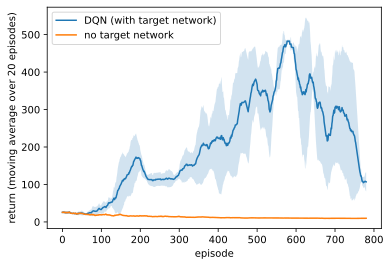

In [3]:

d2l.compare_return_curves({
    'DQN (with target network)': lambda seed: train_dqn(seed, True),
    'no target network': lambda seed: train_dqn(seed, False)}, num_seeds)

The two arms differ in one boolean and end in different worlds. With the target network, every seed reaches the 500 ceiling: each one posts a perfect 20-episode stretch at some point in training, and the median run finishes its final twenty episodes at 460. Without it, no seed ever gets going: returns rise briefly while $\epsilon$ is still large and random exploration props up the buffer, then collapse to roughly 10, which is a pole that falls over immediately, and stay there. The naive recipe is not merely noisier, it fails outright on this problem: the network chases its own targets into a self-confirming collapse, and because the greedy policy is derived from the same broken network, the new data it collects confirms the collapse rather than correcting it. Training remains rougher than anything else in this chapter even in the healthy arm. The curves dip on the way up, and one of our three seeds touches the ceiling and then collapses well below it late in training; this is the generalization coupling of that section compounded by the upward bias of the max, and taming it further is what the tricks beyond this section, from Double DQN onward, are for.

## Summary

DQN is Q-Learning with the table replaced by a network, made stable by two additions. The replay buffer breaks the correlation of consecutive transitions and reuses each one many times, which is legitimate because the Q-Learning target does not depend on the policy that collected the transition. The target network freezes the bootstrap targets between periodic syncs, cutting the feedback loop of a regression that moves its own targets. The max in the target also inflates values, since a maximum of noisy estimates is biased upward; Double DQN reduces the inflation by letting the online network select the action and the frozen network evaluate it. On CartPole, the full recipe reaches the 500 ceiling on every seed while the same code without the target network collapses to an immediately falling pole on every seed.

## Exercises

1. Implement Double DQN by replacing the target computation with the equation. Compare the two on CartPole across several seeds; also track $\max_a Q_\theta(s_0, a)$ at the start state over training and compare it with the returns actually achieved.
1. Sweep the sync period over $C \in \{1, 50, 500, 5000\}$. Explain what $C = 1$ is equivalent to, and why very large $C$ also slows learning.
1. Shrink the replay buffer to 500 transitions and retrain. Which of the two couplings does this reintroduce, and what do the curves look like?
1. DQN stores `float(terminated)` and not `done` in the buffer. Recalling the discussion in that section, what would go wrong with the targets on truncated CartPole episodes if `done` were stored instead?